# Revenue Forecasting Memo — H&S (Hotazel Steam)

**Prepared for:** H&S Management
**Purpose:** Develop and compare two revenue forecasting models that incorporate seasonal dummy variables and interaction terms, and recommend the best model for H&S's revenue forecasting process.

**Dataset:** Monthly data from 2011–2014 containing revenue, production, cooling degree days (coolDD), and heating degree days (heatDD). Data from 2011–2013 is used to train the models, and 2014 data is held out to test forecast accuracy.

**Approach:**
1. Create dummy variables for Winter (months 12, 1, 2) and Summer (months 6, 7, 8)
2. Create interaction terms (production × dummy) so seasons can change both the intercept and the slope
3. Build two models, forecast 2014 revenue with each, and compare using MAPE and adjusted R-squared

## Step 1: Import libraries and load the data

We import our standard libraries: numpy for calculations, pandas for working with dataframes, matplotlib for visualizations, and statsmodels for regression modeling. We also format the display to avoid scientific notation, then import the dataset and display it to confirm the import worked correctly.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.options.display.float_format = '{:.2f}'.format

HS_data = pd.read_csv('AICPA_regressionAnalysisData.csv')

display(HS_data)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


## Step 2: Convert the date column

The date column is imported as text, so we convert it to a datetime type. This lets us extract the month of each row, which we need to build our seasonal dummy variables.

In [ ]:
HS_data['date'] = pd.to_datetime(HS_data['date'])

display(HS_data)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


## Step 3: Create the dummy variables

A dummy variable captures a qualitative condition: it takes a value of 1 when the condition is met and 0 when it is not. Revenue visibly spikes every winter (heating demand) and dips every summer, so we create dummies to capture that seasonal pattern.

Season definitions:
- Winter = months 12, 1, 2
- Spring = months 3, 4, 5
- Summer = months 6, 7, 8
- Fall = months 9, 10, 11

winter_DV = 1 in December/January/February, 0 otherwise.
summer_DV = 1 in June/July/August, 0 otherwise.

In [ ]:
HS_data['winter_DV'] = np.where(HS_data['date'].dt.month.isin([12,1,2]),1,0)
HS_data['summer_DV'] = np.where(HS_data['date'].dt.month.isin([6,7,8]),1,0)

display(HS_data)

,type,date,revenue,production,coolDD,heatDD,winter_DV,summer_DV
0,dt4training,2011-01-31,23304096,659640,0,1021,1,0
1,dt4training,2011-02-28,24552000,686144,0,794,1,0
2,dt4training,2011-03-31,14804728,416464,0,714,0,0
3,dt4training,2011-04-30,11265320,324456,1,354,0,0
4,dt4training,2011-05-31,5945904,151104,72,114,0,0
5,dt4training,2011-06-30,10379712,479264,239,4,0,1
6,dt4training,2011-07-31,13617528,708472,486,0,0,1
7,dt4training,2011-08-31,14092512,687728,346,0,0,1
8,dt4training,2011-09-30,12085472,567424,195,19,0,0
9,dt4training,2011-10-31,11957032,392328,24,223,0,0


## Step 4: Create the interaction terms

The dummy variable on its own only shifts the intercept of the regression line. An interaction term (independent variable × dummy variable) allows the season to also change the slope — i.e., how strongly production translates into revenue during that season.

In [ ]:
HS_data['winter_interaction'] = HS_data['production'] * HS_data['winter_DV']
HS_data['summer_interaction'] = HS_data['production'] * HS_data['summer_DV']

display(HS_data)

,type,date,revenue,production,coolDD,heatDD,winter_DV,summer_DV,winter_interaction,summer_interaction
0,dt4training,2011-01-31,23304096,659640,0,1021,1,0,659640,0
1,dt4training,2011-02-28,24552000,686144,0,794,1,0,686144,0
2,dt4training,2011-03-31,14804728,416464,0,714,0,0,0,0
3,dt4training,2011-04-30,11265320,324456,1,354,0,0,0,0
4,dt4training,2011-05-31,5945904,151104,72,114,0,0,0,0
5,dt4training,2011-06-30,10379712,479264,239,4,0,1,0,479264
6,dt4training,2011-07-31,13617528,708472,486,0,0,1,0,708472
7,dt4training,2011-08-31,14092512,687728,346,0,0,1,0,687728
8,dt4training,2011-09-30,12085472,567424,195,19,0,0,0,0
9,dt4training,2011-10-31,11957032,392328,24,223,0,0,0,0


## Step 5: Separate training and testing data

The dataset is already labeled: 2011–2013 is the training set (used to build the models) and 2014 is the testing set (used to evaluate forecast accuracy on data the models have never seen). We display both to confirm the split worked.

In [ ]:
dt4training = HS_data.loc[HS_data['type']=='dt4training']
dt4testing = HS_data.loc[HS_data['type']=='dt4testing']

display(dt4training)
display(dt4testing)

,type,date,revenue,production,coolDD,heatDD,winter_DV,summer_DV,winter_interaction,summer_interaction
0,dt4training,2011-01-31,23304096,659640,0,1021,1,0,659640,0
1,dt4training,2011-02-28,24552000,686144,0,794,1,0,686144,0
2,dt4training,2011-03-31,14804728,416464,0,714,0,0,0,0
3,dt4training,2011-04-30,11265320,324456,1,354,0,0,0,0
4,dt4training,2011-05-31,5945904,151104,72,114,0,0,0,0
5,dt4training,2011-06-30,10379712,479264,239,4,0,1,0,479264
6,dt4training,2011-07-31,13617528,708472,486,0,0,1,0,708472
7,dt4training,2011-08-31,14092512,687728,346,0,0,1,0,687728
8,dt4training,2011-09-30,12085472,567424,195,19,0,0,0,0
9,dt4training,2011-10-31,11957032,392328,24,223,0,0,0,0


,type,date,revenue,production,coolDD,heatDD,winter_DV,summer_DV,winter_interaction,summer_interaction
36,dt4testing,2014-01-31,19228840,606400,0,1123,1,0,606400,0
37,dt4testing,2014-02-28,26792280,714128,0,938,1,0,714128,0
38,dt4testing,2014-03-31,19935840,805600,0,866,0,0,0,0
39,dt4testing,2014-04-30,13468000,375856,0,412,0,0,0,0
40,dt4testing,2014-05-31,7344128,279296,49,88,0,0,0,0
41,dt4testing,2014-06-30,11196216,517600,230,0,0,1,0,517600
42,dt4testing,2014-07-31,13929472,749472,380,0,0,1,0,749472
43,dt4testing,2014-08-31,12352176,663432,322,0,0,1,0,663432
44,dt4testing,2014-09-30,12628944,701656,178,14,0,0,0,0
45,dt4testing,2014-10-31,9361000,411728,24,166,0,0,0,0


# Model 1: Production + Winter dummy + Winter interaction

**Specification:** revenue = β0 + β1·production + β2·winter_DV + β3·winter_interaction

This model lets winter months have both a different intercept (β2) and a different slope on production (β3) compared to the rest of the year.

In [ ]:
y = dt4training.loc[:,'revenue']
x = dt4training.loc[:,['production','winter_DV','winter_interaction']]
x = sm.add_constant(x)

model1 = sm.OLS(y, x).fit()

model1.params

,0
const,5629257.08
production,13.51
winter_DV,-201742.73
winter_interaction,14.16


## Model 1 equation

revenue = 5,629,257.08 + 13.51·production − 201,742.73·winter_DV + 14.16·winter_interaction

**Non-winter months** (winter_DV = 0, so both dummy terms drop out):
revenue = 5,629,257.08 + 13.51·production

**Winter months** (winter_DV = 1):
revenue = (5,629,257.08 − 201,742.73) + (13.51 + 14.16)·production
revenue = 5,427,514.35 + 27.67·production

Interpretation: in winter, each additional unit of production generates roughly double the revenue (27.67 vs 13.51), holding all other variables constant — consistent with H&S selling steam for heating in winter.

In [ ]:
model1.rsquared_adj

np.float64(0.7517812565787813)

## Test Model 1 on 2014 data

The adjusted R-squared above (0.75) tells us how much of the variation in revenue the model explains on the training data. Now we test forecast accuracy: we prepare the testing set's independent variables (same columns as training, plus the constant), copy the testing data into an assessment dataframe, and use the model to predict 2014 revenue. We then calculate the absolute percentage error for each month, and take the mean to get the MAPE (Mean Absolute Percentage Error) score. The absolute value matters: without it, overshoots and undershoots would net out and make the model look better than it is.

In [ ]:
x_test = dt4testing.loc[:,['production','winter_DV','winter_interaction']]
x_test = sm.add_constant(x_test)

model1_assessment = dt4testing.copy()

model1_assessment['model1_predicted_revenue'] = model1.predict(x_test)

model1_assessment['model1_abs_pct_error'] = abs(
    (
        model1_assessment['revenue'] - model1_assessment['model1_predicted_revenue']
        )/model1_assessment['revenue']
    )

display(model1_assessment)

,type,date,revenue,production,coolDD,heatDD,winter_DV,summer_DV,winter_interaction,summer_interaction,model1_predicted_revenue,model1_abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,1,0,606400,0,22205317.42,0.15
37,dt4testing,2014-02-28,26792280,714128,0,938,1,0,714128,0,25185922.91,0.06
38,dt4testing,2014-03-31,19935840,805600,0,866,0,0,0,0,16509348.78,0.17
39,dt4testing,2014-04-30,13468000,375856,0,412,0,0,0,0,10705408.70,0.21
40,dt4testing,2014-05-31,7344128,279296,49,88,0,0,0,0,9401310.32,0.28
41,dt4testing,2014-06-30,11196216,517600,230,0,0,1,0,517600,12619743.01,0.13
42,dt4testing,2014-07-31,13929472,749472,380,0,0,1,0,749472,15751307.84,0.13
43,dt4testing,2014-08-31,12352176,663432,322,0,0,1,0,663432,14589288.11,0.18
44,dt4testing,2014-09-30,12628944,701656,178,14,0,0,0,0,15105525.23,0.20
45,dt4testing,2014-10-31,9361000,411728,24,166,0,0,0,0,11189880.71,0.20


In [ ]:
model1_assessment['model1_abs_pct_error'].mean()

np.float64(0.15896219012848184)

# Model 2: Production + Winter and Summer dummies + both interactions

**Specification:** revenue = β0 + β1·production + β2·winter_DV + β3·summer_DV + β4·winter_interaction + β5·summer_interaction

Model 1's MAPE score above (0.159) means its forecasts were off by about 15.9% on average. Let's see if we can do better by capturing the full seasonal picture: winter and summer each get their own intercept shift and their own slope on production. Spring/fall act as the baseline (both dummies = 0).

In [ ]:
y = dt4training.loc[:,'revenue']
x = dt4training.loc[:,['production','winter_DV','summer_DV','winter_interaction','summer_interaction']]
x = sm.add_constant(x)

model2 = sm.OLS(y, x).fit()

model2.params

,0
const,4060734.59
production,18.87
winter_DV,1366779.75
summer_DV,1392019.04
winter_interaction,8.80
summer_interaction,-6.28


## Model 2 equation

revenue = 4,060,734.59 + 18.87·production + 1,366,779.75·winter_DV + 1,392,019.04·summer_DV + 8.80·winter_interaction − 6.28·summer_interaction

**Spring/Fall months** (both dummies = 0, all dummy terms drop out):
revenue = 4,060,734.59 + 18.87·production

**Winter months** (winter_DV = 1):
revenue = (4,060,734.59 + 1,366,779.75) + (18.87 + 8.80)·production
revenue = 5,427,514.34 + 27.67·production

**Summer months** (summer_DV = 1):
revenue = (4,060,734.59 + 1,392,019.04) + (18.87 − 6.28)·production
revenue = 5,452,753.63 + 12.59·production

Interpretation: each unit of production earns the most revenue in winter (27.67), a baseline amount in spring/fall (18.87), and the least in summer (12.59). This matches the economics of the business — winter steam serves high-value heating demand, while summer production serves lower-value cooling.

In [ ]:
model2.rsquared_adj

np.float64(0.7570273783732417)

## Test Model 2 on 2014 data

Same process as Model 1: prepare the testing independent variables with the constant, predict 2014 revenue, and calculate the MAPE score.

In [ ]:
x_test2 = dt4testing.loc[:,['production','winter_DV','summer_DV','winter_interaction','summer_interaction']]
x_test2 = sm.add_constant(x_test2)

model2_assessment = dt4testing.copy()

model2_assessment['model2_predicted_revenue'] = model2.predict(x_test2)

model2_assessment['model2_abs_pct_error'] = abs(
    (
        model2_assessment['revenue'] - model2_assessment['model2_predicted_revenue']
        )/model2_assessment['revenue']
    )

display(model2_assessment)

,type,date,revenue,production,coolDD,heatDD,winter_DV,summer_DV,winter_interaction,summer_interaction,model2_predicted_revenue,model2_abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,1,0,606400,0,22205317.42,0.15
37,dt4testing,2014-02-28,26792280,714128,0,938,1,0,714128,0,25185922.91,0.06
38,dt4testing,2014-03-31,19935840,805600,0,866,0,0,0,0,19263798.27,0.03
39,dt4testing,2014-04-30,13468000,375856,0,412,0,0,0,0,11153786.61,0.17
40,dt4testing,2014-05-31,7344128,279296,49,88,0,0,0,0,9331532.60,0.27
41,dt4testing,2014-06-30,11196216,517600,230,0,0,1,0,517600,11969955.80,0.07
42,dt4testing,2014-07-31,13929472,749472,380,0,0,1,0,749472,14889501.20,0.07
43,dt4testing,2014-08-31,12352176,663432,322,0,0,1,0,663432,13806154.84,0.12
44,dt4testing,2014-09-30,12628944,701656,178,14,0,0,0,0,17302195.43,0.37
45,dt4testing,2014-10-31,9361000,411728,24,166,0,0,0,0,11830753.22,0.26


In [ ]:
model2_assessment['model2_abs_pct_error'].mean()

np.float64(0.14875247200876243)

# Model Comparison

The visualization below plots actual 2014 revenue (green) against each model's forecasts (blue = Model 1, red = Model 2). The closer a forecast line tracks the green line, the better the model. The table that follows summarizes both performance metrics side by side.

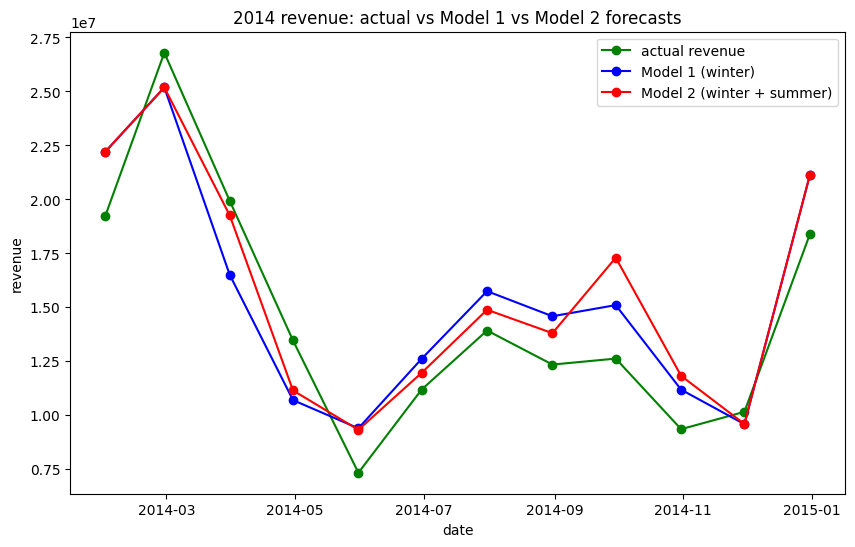

In [ ]:
plt.figure(figsize=(10,6))

plt.title('2014 revenue: actual vs Model 1 vs Model 2 forecasts')
plt.ylabel('revenue')
plt.xlabel('date')

plt.plot(model1_assessment['date'], model1_assessment['revenue'], marker='o', color='green', label='actual revenue')
plt.plot(model1_assessment['date'], model1_assessment['model1_predicted_revenue'], marker='o', color='blue', label='Model 1 (winter)')
plt.plot(model2_assessment['date'], model2_assessment['model2_predicted_revenue'], marker='o', color='red', label='Model 2 (winter + summer)')

plt.legend()

In [ ]:
comparison = pd.DataFrame({
    'model': ['Model 1: production + winter_DV + winter_interaction',
              'Model 2: production + winter_DV + summer_DV + both interactions'],
    'adjusted_r_squared': [model1.rsquared_adj, model2.rsquared_adj],
    'MAPE': [model1_assessment['model1_abs_pct_error'].mean(),
             model2_assessment['model2_abs_pct_error'].mean()]
})

display(comparison)

,model,adjusted_r_squared,MAPE
0,Model 1: production + winter_DV + winter_inter...,0.75,0.16
1,Model 2: production + winter_DV + summer_DV + ...,0.76,0.15


## Visualizing the recommended model's regression lines

Model 2 is our recommended model (lower MAPE and higher adjusted R-squared — see comparison above). For a regression with dummy variables, one equation produces multiple lines. Below we scatter the actual training data points, extract the coefficients from the model, build each seasonal line, and plot them. The three lines show how the single Model 2 equation adapts to winter, summer, and spring/fall conditions.

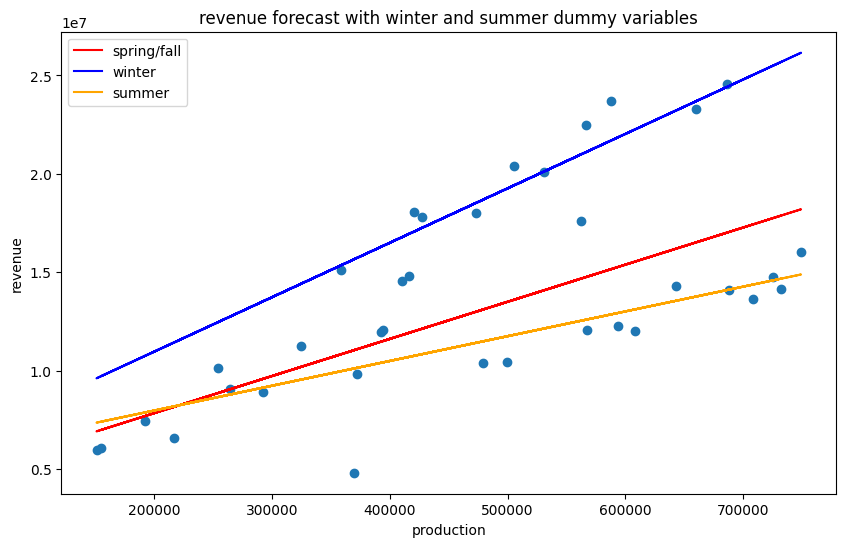

In [ ]:
plt.figure(figsize=(10,6))

plt.title('revenue forecast with winter and summer dummy variables')
plt.xlabel('production')
plt.ylabel('revenue')

# step 1: scatter plot the actual data points
plt.scatter(dt4training['production'], dt4training['revenue'])

# step 2: extract the coefficients from our model
intercept, production_coefficient, winter_DV_intercept, summer_DV_intercept, winter_coefficient, summer_coefficient = model2.params

# step 3: create individual lines for each season
spring_fall_line = intercept + production_coefficient * dt4training['production']

winter_line = (intercept + winter_DV_intercept) + (production_coefficient + winter_coefficient) * dt4training['production']

summer_line = (intercept + summer_DV_intercept) + (production_coefficient + summer_coefficient) * dt4training['production']

# step 4: plot the lines
plt.plot(dt4training['production'], spring_fall_line, color='red', label='spring/fall')
plt.plot(dt4training['production'], winter_line, color='blue', label='winter')
plt.plot(dt4training['production'], summer_line, color='orange', label='summer')

plt.legend()

# Final Memo

**To:** H&S Management
**From:** Ali Ghuman
**Re:** Recommended revenue forecasting model

**Process:** We built two forecasting models on 2011–2013 monthly data and tested their accuracy on held-out 2014 data. Both models incorporate seasonal dummy variables (which shift the baseline level of revenue in a given season) and interaction terms (which change how strongly production drives revenue in that season). "Winter" is defined as December–February and "summer" as June–August.

**Models tested:**
- Model 1: revenue predicted by production, a winter dummy variable, and a winter interaction term
- Model 2: revenue predicted by production, winter and summer dummy variables, and both interaction terms

**Findings:**
- Model 1 — adjusted R-squared: 0.75, MAPE: 0.159 (2014 forecasts off by ~15.9% on average)
- Model 2 — adjusted R-squared: 0.76, MAPE: 0.149 (2014 forecasts off by ~14.9% on average)

**Recommendation:** We recommend Model 2. It has the lowest MAPE score, meaning its 2014 revenue forecasts were the most accurate — off by an average of 14.9%, compared to 15.9% for Model 1 — and it also has the higher adjusted R-squared, meaning it explains more of the variation in revenue. The seasonal structure of Model 2 matches the economics of the business: each unit of production earns the most revenue in winter (heating demand), a baseline amount in spring/fall, and the least in summer (lower-value cooling), so allowing both seasons to change the intercept and the slope of the production relationship materially improves forecast accuracy. Model 2 also suggests business insights worth exploring, such as differential seasonal pricing and enhanced revenue auditing expectations by season.